# **BISI: 24F_CST2111**
# **Group8: Digital Pulse**


# **Analysing Covid 19 dataset**

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

In [ ]:

# import Cleaned_data.xlsx into df
df = pd.read_excel('./Cleaned_data_.xlsx')

# convert PostDate from String to Datetime to visualize trend over time
df['PostDate'] = pd.to_datetime(df['PostDate'])

# sort df by PostDate
df = df.sort_values(by='PostDate')

df.head()

,Region,ConversationID,Retweets,Replies,Likes,Quotes,EngagementScore,PostDate,WorkingHours,DayName,...,UserDrives,FirstPersonCount,ThirdPersonCount,InsightScore,CausalityScore,DiscrepancyScore,CertaintyScore,PositiveSentiment,NegativeSentiment,NetSentiment
0,Goa,S1110067634328895488,10,1,50,0,82,2019-03-25,Non-working Hours,Monday,...,0.00,0.00,0.0,3.45,0.0,0.0,0.0,3,-1,2
13,WestBengal,S1110223472913842187,33,1,173,1,274,2019-03-25,Working Hours,Monday,...,2.56,0.00,0.0,0.00,0.0,0.0,0.0,1,-1,0
12,Uttarkhand,S1110185203689881600,3,0,10,0,19,2019-03-25,Working Hours,Monday,...,5.26,0.00,0.0,0.00,0.0,0.0,0.0,1,-1,0
11,Uttarkhand,S1110071400629334016,4,1,24,0,38,2019-03-25,Non-working Hours,Monday,...,4.35,0.00,0.0,0.00,0.0,0.0,0.0,1,-1,0
9,UP,S1110062193582768129,12,0,45,1,81,2019-03-25,Non-working Hours,Monday,...,0.00,2.08,0.0,4.17,0.0,0.0,0.0,4,-1,3


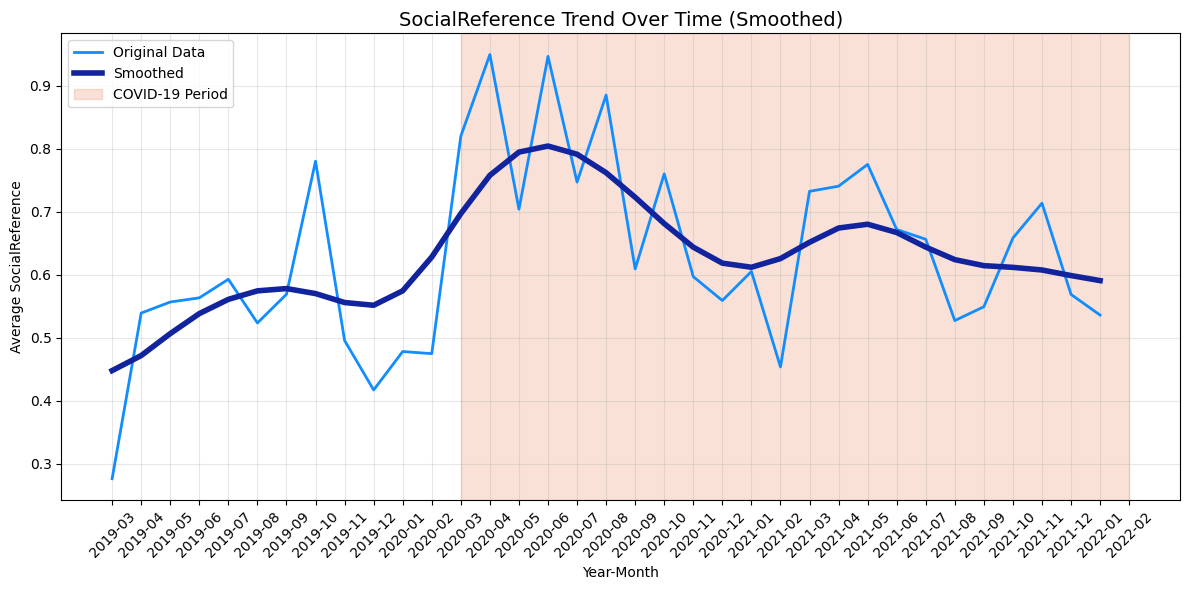

In [ ]:

# Convert 'PostDate' to datetime format
df['PostDate'] = pd.to_datetime(df['PostDate'])

# Extract year and month for analysis
df['YearMonth'] = df['PostDate'].dt.to_period('M')

# Aggregate SocialReference usage over time
social_reference_trend = df.groupby('YearMonth')['SocialReference'].mean().reset_index()

# Smooth the SocialReference trend using a Gaussian filter
social_reference_trend['Smoothed'] = gaussian_filter1d(social_reference_trend['SocialReference'], sigma=2)

# Highlight the COVID-19 period
covid_start = '2020-03'
covid_end = '2022-02'

# Plot SocialReference trend with smoothing
plt.figure(figsize=(12, 6))

# Original data
plt.plot(social_reference_trend['YearMonth'].astype(str),
         social_reference_trend['SocialReference'],
         label='Original Data', color='#118dff', alpha=1,linewidth=2)

# Draw Smoothed line
plt.plot(social_reference_trend['YearMonth'].astype(str),
         social_reference_trend['Smoothed'],
         label='Smoothed', color='#12239e', linewidth=4)

# Highlight COVID-19 period
plt.axvspan(covid_start, covid_end, color='#e56c37', alpha=0.2, label='COVID-19 Period')

# Customize plot
plt.title('SocialReference Trend Over Time (Smoothed)', fontsize=14)
plt.xlabel('Year-Month')
plt.ylabel('Average SocialReference')
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)

# Show plot
plt.tight_layout()
plt.show()

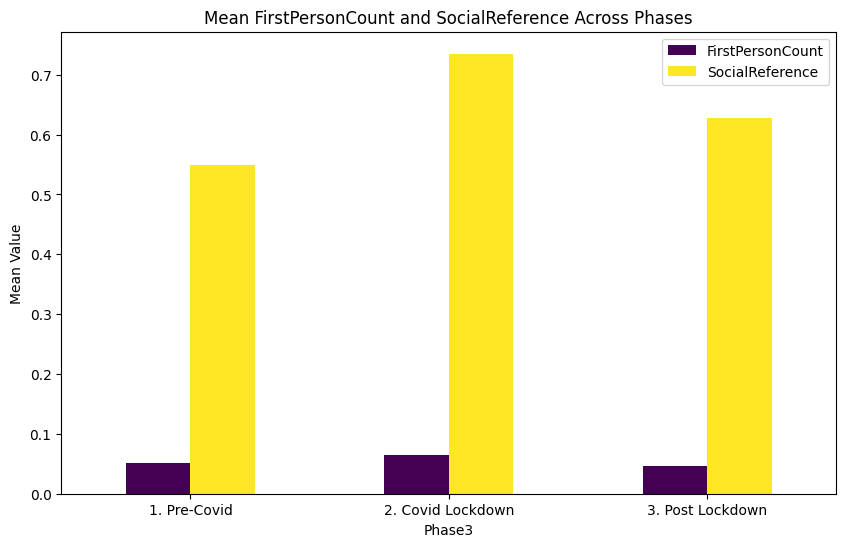

In [ ]:
# analyzing Individual vs Collective Tone in tweets' texts
phase_means = df.groupby('Phase3')[['FirstPersonCount', 'SocialReference']].mean()
phase_means.plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title("Mean FirstPersonCount and SocialReference Across Phases")
plt.ylabel("Mean Value")
plt.xlabel("Phase3")
plt.xticks(rotation=0)
plt.show()


Random Forest - MSE: 3.0976547388926385
Random Forest - R2 Score: -0.12044861629567594


<ipython-input-20-367a231304c3>:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x='Importance', y='Feature', palette='viridis')


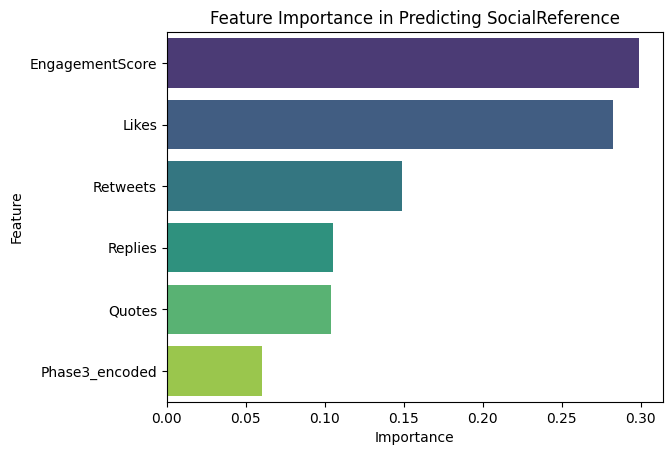

<ipython-input-20-367a231304c3>:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Phase3', y='Predicted_SocialReference', palette='coolwarm')


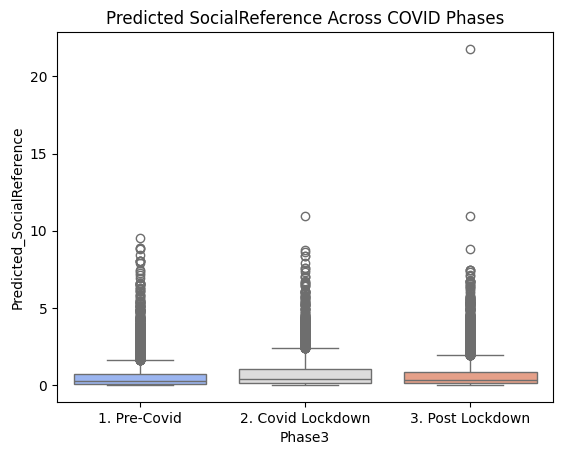

<ipython-input-20-367a231304c3>:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mean_values, x='Phase3', y='Predicted_SocialReference', palette='rocket')


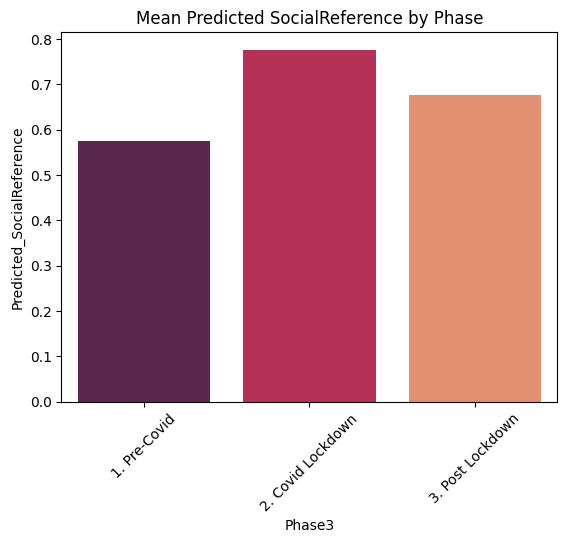

In [ ]:
# Analyzing feature importance to predict SocialReference with random forest

# Encode categorical data for Phase3
le = LabelEncoder()
df['Phase3_encoded'] = le.fit_transform(df['Phase3'])

# Select features and target
features = ['Phase3_encoded', 'Likes', 'Retweets', 'Replies', 'Quotes', 'EngagementScore']
target = 'SocialReference'

X = df[features]
y = df[target]

# Split into train-test datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate model performance
y_pred = rf_model.predict(X_test)
print("Random Forest - MSE:", mean_squared_error(y_test, y_pred))
print("Random Forest - R2 Score:", r2_score(y_test, y_pred))

# Feature Importance
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

sns.barplot(data=importances, x='Importance', y='Feature', palette='viridis')
plt.title("Feature Importance in Predicting SocialReference")
plt.show()

# Predict the impact of COVID (Phase3) on SocialReference
df['Predicted_SocialReference'] = rf_model.predict(X)

# Compare actual and predicted SocialReference across phases
sns.boxplot(data=df, x='Phase3', y='Predicted_SocialReference', palette='coolwarm')
plt.title("Predicted SocialReference Across COVID Phases")
plt.show()

# Analyze mean predicted values per phase
mean_values = df.groupby('Phase3')['Predicted_SocialReference'].mean().reset_index()
sns.barplot(data=mean_values, x='Phase3', y='Predicted_SocialReference', palette='rocket')
plt.title("Mean Predicted SocialReference by Phase")
plt.xticks(rotation=45)
plt.show()


In [ ]:
df.columns

Index(['Region', 'ConversationID', 'Retweets', 'Replies', 'Likes', 'Quotes',
       'EngagementScore', 'PostDate', 'WorkingHours', 'DayName', 'WeekStatus',
       'TimeCategory', 'Phase3', 'Phase4', 'FollowerCount', 'MediaType',
       'ContentCategory', 'WordCount', 'ConfidenceScore', 'CognitiveScore',
       'EmotionalTone', 'EmotionScore', 'PositiveEmotion', 'NegativeEmotion',
       'SocialReference', 'UncertaintyScore', 'UserDrives', 'FirstPersonCount',
       'ThirdPersonCount', 'InsightScore', 'CausalityScore',
       'DiscrepancyScore', 'CertaintyScore', 'PositiveSentiment',
       'NegativeSentiment', 'NetSentiment'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23006 entries, 0 to 23005
Data columns (total 36 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Region             23006 non-null  object        
 1   ConversationID     23006 non-null  object        
 2   Retweets           23006 non-null  int64         
 3   Replies            23006 non-null  int64         
 4   Likes              23006 non-null  int64         
 5   Quotes             23006 non-null  int64         
 6   EngagementScore    23006 non-null  int64         
 7   PostDate           23006 non-null  datetime64[ns]
 8   WorkingHours       23006 non-null  object        
 9   DayName            23006 non-null  object        
 10  WeekStatus         23006 non-null  object        
 11  TimeCategory       23006 non-null  object        
 12  Phase3             23006 non-null  object        
 13  Phase4             23006 non-null  object        
 14  FollowerCou

In [ ]:
# for correlation matrix
# keep only columns where type is a number
df = df.select_dtypes(include=['number'])

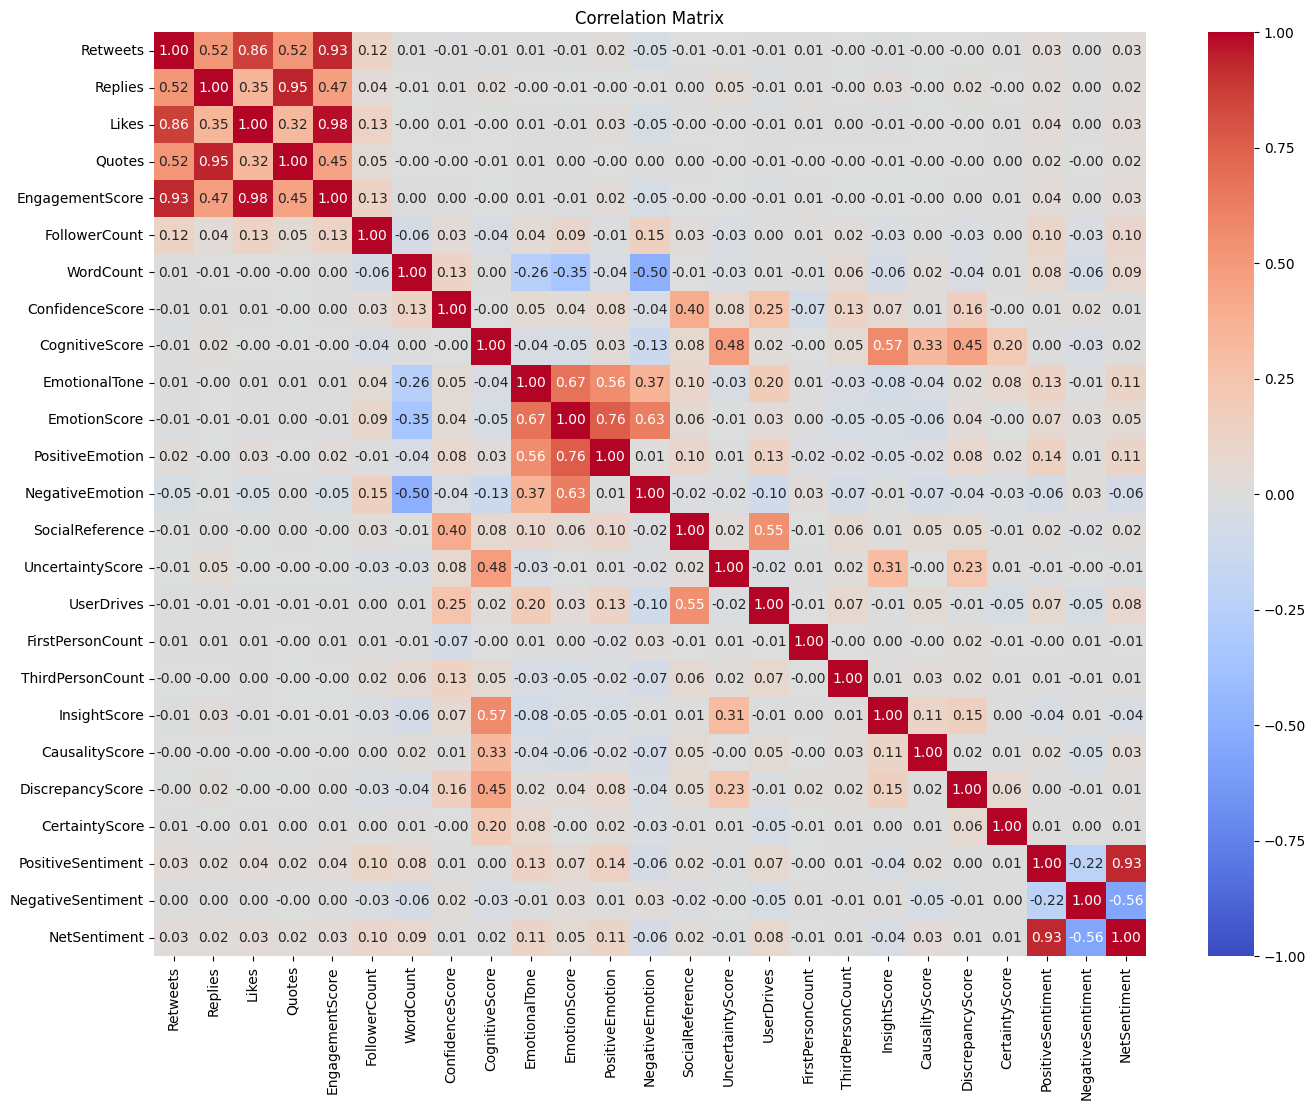

In [ ]:
import numpy as np

correlation_matrix = df.corr()
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()


# **Analysing Time Zones dataset**

In [3]:
df = pd.read_csv('social_media_engagement_vs_time_zones.csv')

In [4]:
df.shape

(11975, 25)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11975 entries, 0 to 11974
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Post_ID                       11975 non-null  object 
 1   User_ID                       11975 non-null  object 
 2   Platform                      11975 non-null  object 
 3   Post_Type                     11975 non-null  object 
 4   Post_Time_UTC                 11975 non-null  object 
 5   Post_Time_Local               11975 non-null  object 
 6   Time_Zone                     11975 non-null  object 
 7   Engagement_Start_Time_UTC     11975 non-null  object 
 8   Engagement_Start_Time_Local   11975 non-null  object 
 9   Total_Engagements             11975 non-null  int64  
 10  Likes                         11975 non-null  int64  
 11  Comments                      11975 non-null  int64  
 12  Shares                        11975 non-null  int64  
 13  E

In [6]:
df.describe()

,Total_Engagements,Likes,Comments,Shares,Engagement_Within_1_Hour,Engagement_Within_24_Hours,User_Followers_Count,Engagement_Rate_Per_Follower,Content_Length
count,11975.000000,11975.000000,11975.000000,11975.000000,11975.000000,11975.000000,11975.000000,11975.000000,11975.000000
mean,498.138038,249.377871,125.238747,123.521420,247.719666,373.907891,25034.550063,0.069181,77.265052
std,289.932531,222.704020,147.568320,145.509628,218.757712,252.355030,14438.054240,0.380774,110.419217
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,54.000000,0.000000,5.000000
25%,245.000000,67.000000,20.000000,18.000000,64.000000,156.000000,12439.000000,0.009848,22.000000
50%,499.000000,186.000000,68.000000,69.000000,186.000000,340.000000,25001.000000,0.019926,39.000000
75%,746.000000,378.000000,178.000000,176.000000,381.000000,563.000000,37557.500000,0.039311,56.000000
max,1000.000000,996.000000,931.000000,939.000000,983.000000,998.000000,49998.000000,17.090909,500.000000


In [7]:
df.head()

,Post_ID,User_ID,Platform,Post_Type,Post_Time_UTC,Post_Time_Local,Time_Zone,Engagement_Start_Time_UTC,Engagement_Start_Time_Local,Total_Engagements,...,Geolocation,User_Followers_Count,Hashtags_Used,Engagement_Rate_Per_Follower,Day_of_Week,Time_of_Day_Category,Content_Length,Engagement_Peak_Time_UTC,Engagement_Peak_Time_Local,Content_Topic
0,f0cae208-dcea-48dc-a5c0-97f19a631511,1c4e3ec4-fa85-447e-b6f3-926286b84000,Instagram,story,23/01/2024 11:58,23/01/2024 22:58,UTC-8,23/01/2024 12:12,23/01/2024 1:12,762,...,East Danny,19616,"east, edge, red, start, if",0.038846,Tuesday,Morning,16,24/01/2024 0:02,24/01/2024 9:02,education
1,e3aec9a2-b741-444d-852b-55475b92268d,bb9ef156-8b9d-45d8-9a92-f650fed94e3c,LinkedIn,reel,06/01/2024 2:34,06/01/2024 12:34,UTC+5:30,06/01/2024 3:44,06/01/2024 4:44,23,...,Lake Thomastown,15755,particular,0.001460,Thursday,Afternoon,7,06/01/2024 17:50,06/01/2024 9:50,education
2,23362bba-79b5-4ff6-a1bb-1c1a709a76e9,eb94f7d9-c441-4413-a060-d7df3e77fb8b,LinkedIn,image,15/08/2024 8:11,15/08/2024 2:11,UTC+8,15/08/2024 8:14,15/08/2024 12:14,474,...,Brewerstad,22751,will,0.020834,Tuesday,Morning,31,15/08/2024 22:35,15/08/2024 19:35,fitness
3,c01eea4c-c198-45e2-b07a-ec53258b3f6a,8f13828c-4120-4252-bb23-8d1dd87c3f7c,Twitter,video,17/07/2024 5:30,17/07/2024 10:30,UTC+8,17/07/2024 7:02,17/07/2024 3:02,980,...,New Taraside,40224,"word, that, ready, him",0.024364,Wednesday,Evening,49,17/07/2024 8:52,17/07/2024 17:52,tech
4,9a02629b-0e26-49b7-ab29-18ab8d39f0b8,6c53c2ab-fbd7-4ae3-bec4-64c40a978a44,Facebook,video,07/04/2024 0:26,07/04/2024 0:26,UTC-5,07/04/2024 2:16,07/04/2024 3:16,587,...,West Leahport,34688,rock,0.016922,Sunday,Night,8,07/04/2024 23:19,08/04/2024 8:19,lifestyle


In [8]:
# drop the columns Post_Time_UTC, Engagement_Start_Time_UTC, Engagement_Peak_Time_UTC
df.drop(['Post_Time_UTC', 'Engagement_Start_Time_UTC', 'Engagement_Peak_Time_UTC'], axis=1, inplace=True)


In [9]:
# Split the column Post_Time_Local into two columns, Post Date, Post Time
df[['Post Date', 'Post Time']] = df['Post_Time_Local'].str.split(' ', expand=True)

In [10]:
# Split the column Engagement_Start_Time_Local into two columns, Engagement Date, Engagement Time
df[['Engagement Date', 'Engagement Time']] = df['Engagement_Start_Time_Local'].str.split(' ', expand=True)

In [11]:
# Split the column Engagement_Peak_Time_Local into two columns, Engagement_Peak Date, Engagement_Peak Time
df[['Engagement_Peak Date', 'Engagement_Peak Time']] = df['Engagement_Peak_Time_Local'].str.split(' ', expand=True)


In [12]:
# Insert a new column call it Day type to map the days of the weeks in column Day_of_Week to Weekday for days Monday, tuesday, wednesday, thursday, Fidriday, and weekend for saturday and sunday
df['Day type'] = df['Day_of_Week'].apply(lambda x: 'Weekday' if x in ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'] else 'Weekend')

In [13]:
df.head()

,Post_ID,User_ID,Platform,Post_Type,Post_Time_Local,Time_Zone,Engagement_Start_Time_Local,Total_Engagements,Likes,Comments,...,Content_Length,Engagement_Peak_Time_Local,Content_Topic,Post Date,Post Time,Engagement Date,Engagement Time,Engagement_Peak Date,Engagement_Peak Time,Day type
0,f0cae208-dcea-48dc-a5c0-97f19a631511,1c4e3ec4-fa85-447e-b6f3-926286b84000,Instagram,story,23/01/2024 22:58,UTC-8,23/01/2024 1:12,762,195,33,...,16,24/01/2024 9:02,education,23/01/2024,22:58,23/01/2024,1:12,24/01/2024,9:02,Weekday
1,e3aec9a2-b741-444d-852b-55475b92268d,bb9ef156-8b9d-45d8-9a92-f650fed94e3c,LinkedIn,reel,06/01/2024 12:34,UTC+5:30,06/01/2024 4:44,23,20,0,...,7,06/01/2024 9:50,education,06/01/2024,12:34,06/01/2024,4:44,06/01/2024,9:50,Weekday
2,23362bba-79b5-4ff6-a1bb-1c1a709a76e9,eb94f7d9-c441-4413-a060-d7df3e77fb8b,LinkedIn,image,15/08/2024 2:11,UTC+8,15/08/2024 12:14,474,52,144,...,31,15/08/2024 19:35,fitness,15/08/2024,2:11,15/08/2024,12:14,15/08/2024,19:35,Weekday
3,c01eea4c-c198-45e2-b07a-ec53258b3f6a,8f13828c-4120-4252-bb23-8d1dd87c3f7c,Twitter,video,17/07/2024 10:30,UTC+8,17/07/2024 3:02,980,452,504,...,49,17/07/2024 17:52,tech,17/07/2024,10:30,17/07/2024,3:02,17/07/2024,17:52,Weekday
4,9a02629b-0e26-49b7-ab29-18ab8d39f0b8,6c53c2ab-fbd7-4ae3-bec4-64c40a978a44,Facebook,video,07/04/2024 0:26,UTC-5,07/04/2024 3:16,587,111,177,...,8,08/04/2024 8:19,lifestyle,07/04/2024,0:26,07/04/2024,3:16,08/04/2024,8:19,Weekend


In [14]:
# save the dataframe to a csv file
df.to_csv('social_media_engagement_vs_time_zones_cleaned2.csv', index=False)

In [15]:
df.shape

(11975, 29)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11975 entries, 0 to 11974
Data columns (total 29 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Post_ID                       11975 non-null  object 
 1   User_ID                       11975 non-null  object 
 2   Platform                      11975 non-null  object 
 3   Post_Type                     11975 non-null  object 
 4   Post_Time_Local               11975 non-null  object 
 5   Time_Zone                     11975 non-null  object 
 6   Engagement_Start_Time_Local   11975 non-null  object 
 7   Total_Engagements             11975 non-null  int64  
 8   Likes                         11975 non-null  int64  
 9   Comments                      11975 non-null  int64  
 10  Shares                        11975 non-null  int64  
 11  Engagement_Within_1_Hour      11975 non-null  int64  
 12  Engagement_Within_24_Hours    11975 non-null  int64  
 13  G

In [17]:
df.corr(numeric_only=True)

,Total_Engagements,Likes,Comments,Shares,Engagement_Within_1_Hour,Engagement_Within_24_Hours,User_Followers_Count,Engagement_Rate_Per_Follower,Content_Length
Total_Engagements,1.000000,0.660549,0.487808,0.486845,0.652518,0.868128,0.010812,0.112170,-0.006468
Likes,0.660549,1.000000,-0.109810,-0.102983,0.435957,0.574234,0.012244,0.058932,0.000290
Comments,0.487808,-0.109810,1.000000,0.125889,0.316485,0.426389,0.006048,0.078316,-0.000376
Shares,0.486845,-0.102983,0.125889,1.000000,0.311964,0.418479,-0.003329,0.053881,-0.012951
Engagement_Within_1_Hour,0.652518,0.435957,0.316485,0.311964,1.000000,0.807166,-0.001456,0.085414,-0.019122
Engagement_Within_24_Hours,0.868128,0.574234,0.426389,0.418479,0.807166,1.000000,0.003434,0.105587,-0.007442
User_Followers_Count,0.010812,0.012244,0.006048,-0.003329,-0.001456,0.003434,1.000000,-0.224436,0.001291
Engagement_Rate_Per_Follower,0.112170,0.058932,0.078316,0.053881,0.085414,0.105587,-0.224436,1.000000,0.011008
Content_Length,-0.006468,0.000290,-0.000376,-0.012951,-0.019122,-0.007442,0.001291,0.011008,1.000000


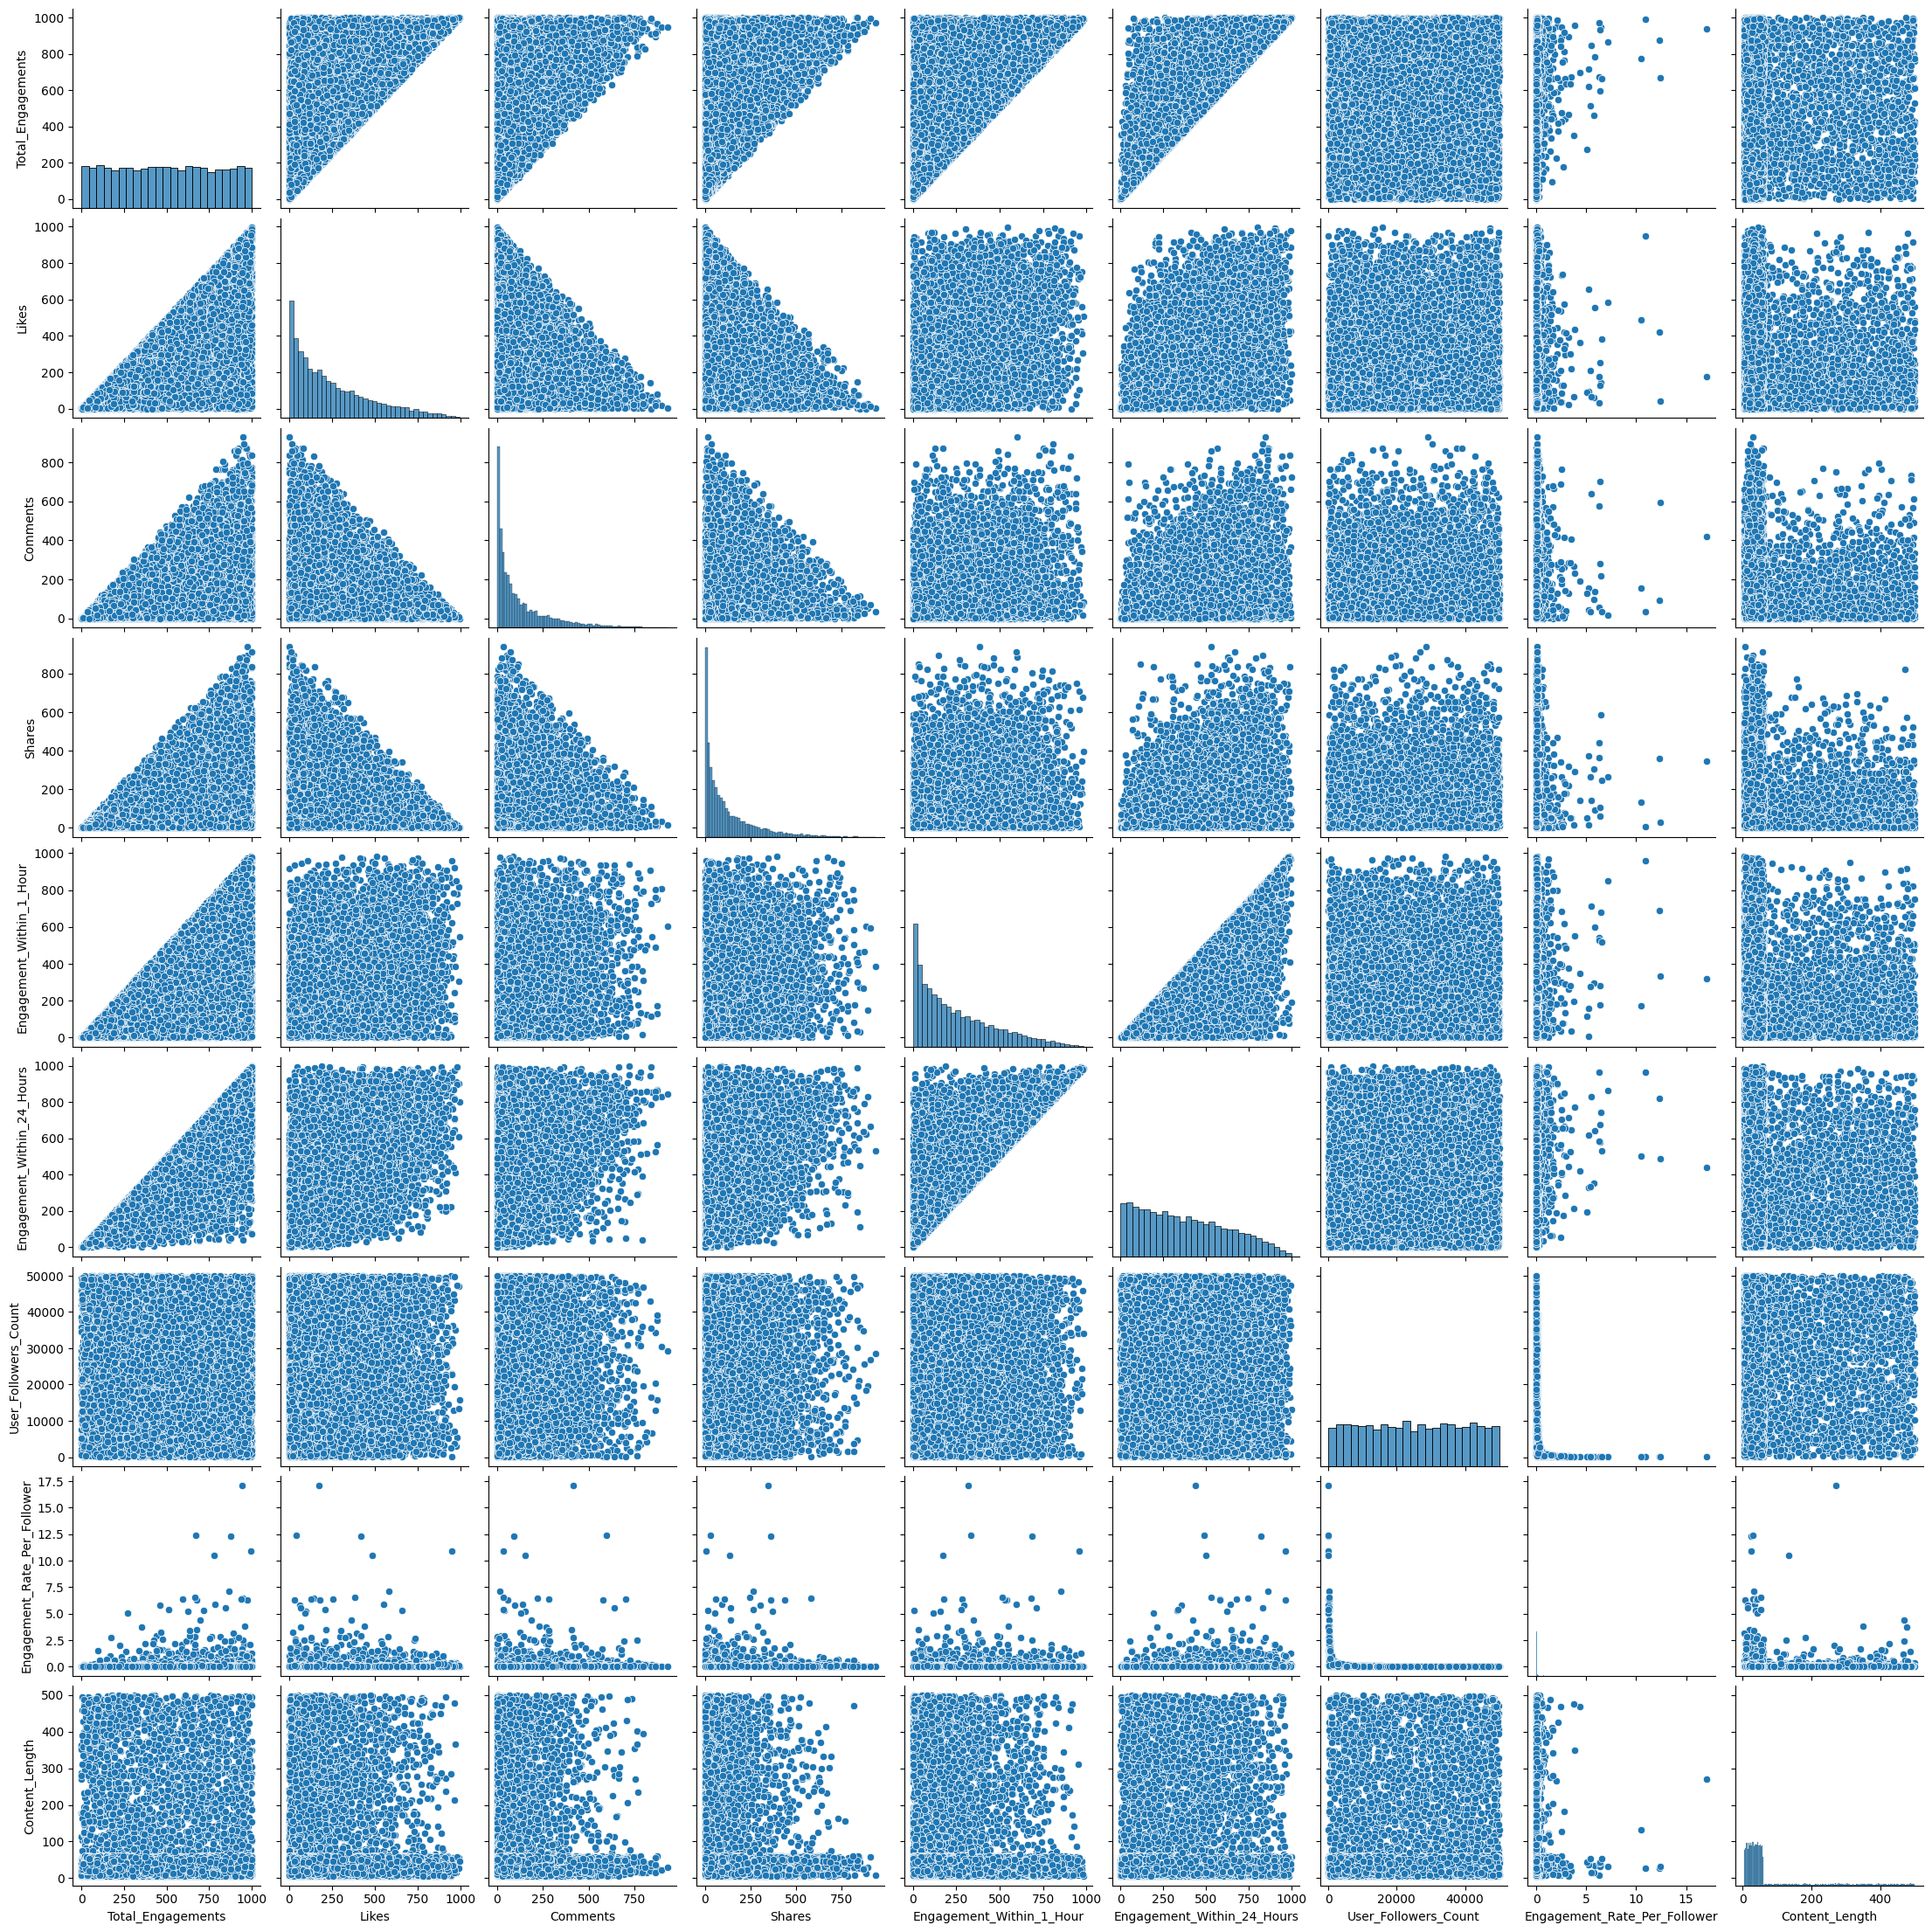

In [18]:
# Plot histogram grid using seaborn pairplot
sns.pairplot(df)

# Clear the text "residue"
plt.show()

# **Analysing Sentiments dataset**

In [ ]:
# Load the cleaned dataset
file_path = 'cleaned_smmh.csv'  # Replace with the correct path if needed
data = pd.read_csv(file_path)

In [ ]:
# Ensure necessary columns are present
columns_to_check = ['AvgTimeOnSM', 'FeelingDown', 'ValidationSeeking', 'EasilyDistracted', 'Gender', 'Age']
data = data[[col for col in columns_to_check if col in data.columns]].dropna()

In [ ]:
# Descriptive Statistics
descriptive_stats = data.describe()
print("Descriptive Statistics:\n", descriptive_stats)

Descriptive Statistics:
        FeelingDown  ValidationSeeking  EasilyDistracted        Age
count   481.000000         481.000000        481.000000  481.00000
mean      3.255717           2.455301          3.349272   26.13659
std       1.313033           1.247739          1.175552    9.91511
min       1.000000           1.000000          1.000000   13.00000
25%       2.000000           1.000000          3.000000   21.00000
50%       3.000000           2.000000          3.000000   22.00000
75%       4.000000           3.000000          4.000000   26.00000
max       5.000000           5.000000          5.000000   91.00000


In [ ]:
# Gender-Based Analysis
gender_analysis = data.groupby('Gender')[['FeelingDown', 'ValidationSeeking', 'EasilyDistracted']].mean()
print("\nGender-Based Analysis:\n", gender_analysis)


Gender-Based Analysis:
                      FeelingDown  ValidationSeeking  EasilyDistracted
Gender                                                               
Female                  3.387833           2.505703          3.422053
Male                    3.075829           2.383886          3.232227
NB                      4.000000           2.000000          3.000000
Non binary              5.000000           5.000000          5.000000
Non-binary              4.000000           2.000000          3.000000
Nonbinary               4.000000           1.000000          4.000000
There are others???     1.000000           2.000000          5.000000
Trans                   5.000000           5.000000          5.000000
unsure                  3.000000           2.000000          4.000000


In [ ]:
# Age-Based Trends
age_analysis = data.groupby('Age')[['FeelingDown', 'ValidationSeeking', 'EasilyDistracted']].mean()
print("\nAge-Based Trends:\n", age_analysis)


Age-Based Trends:
       FeelingDown  ValidationSeeking  EasilyDistracted
Age                                                   
13.0     2.500000           1.500000          3.500000
14.0     2.750000           2.000000          3.250000
15.0     3.000000           2.000000          3.000000
16.0     2.500000           2.500000          4.000000
17.0     3.222222           2.000000          3.333333
18.0     3.615385           2.076923          3.307692
19.0     3.210526           2.315789          3.263158
20.0     3.577778           2.688889          3.466667
21.0     3.573171           2.548780          3.658537
22.0     3.358025           2.617284          3.580247
23.0     3.595238           2.571429          3.476190
24.0     3.518519           2.592593          3.370370
25.0     3.823529           2.529412          3.176471
26.0     3.500000           2.333333          3.444444
26.7     4.000000           3.000000          3.000000
27.0     3.363636           2.636364         

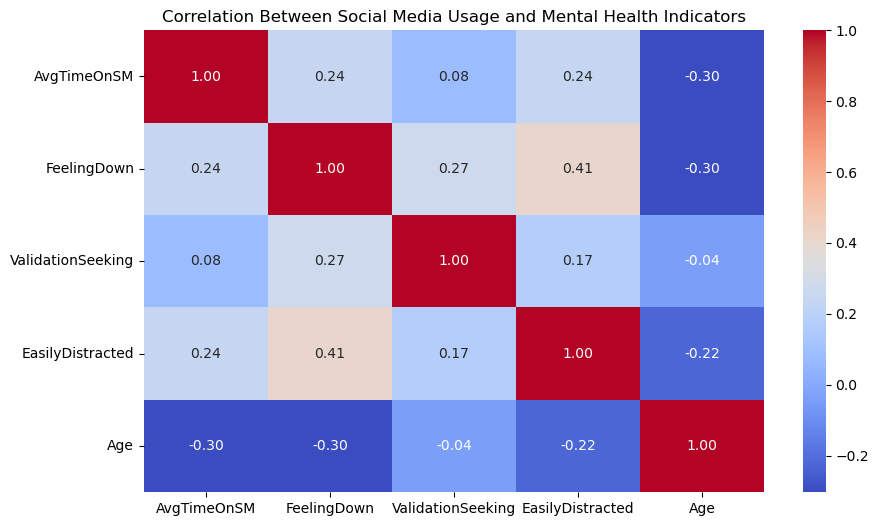

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Social Media Usage and Mental Health Indicators')
plt.show()

/var/folders/cj/m2vmffv12_12n55rcgbv_1xc0000gn/T/ipykernel_17933/2487389698.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='AvgTimeOnSM', y='FeelingDown', data=data, palette='Blues')


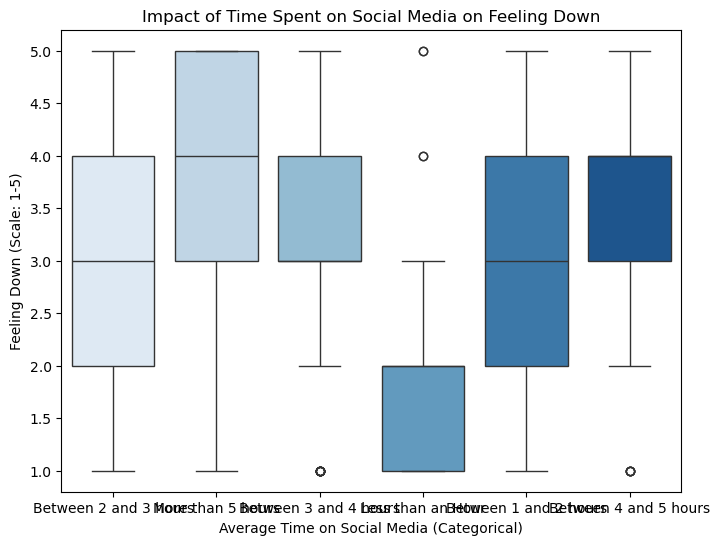

In [ ]:
# Boxplot: Time on Social Media vs. Feeling Down
plt.figure(figsize=(8, 6))
sns.boxplot(x='AvgTimeOnSM', y='FeelingDown', data=data, palette='Blues')
plt.title('Impact of Time Spent on Social Media on Feeling Down')
plt.xlabel('Average Time on Social Media (Categorical)')
plt.ylabel('Feeling Down (Scale: 1-5)')
plt.show()

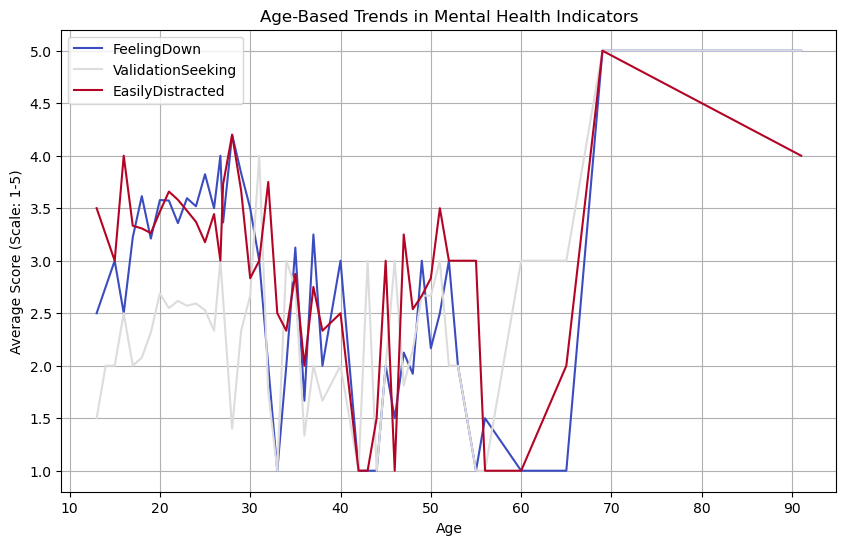

In [ ]:
# Line Plot for Age Analysis
age_analysis.plot(figsize=(10, 6), colormap='coolwarm')
plt.title('Age-Based Trends in Mental Health Indicators')
plt.ylabel('Average Score (Scale: 1-5)')
plt.xlabel('Age')
plt.grid(True)
plt.show()

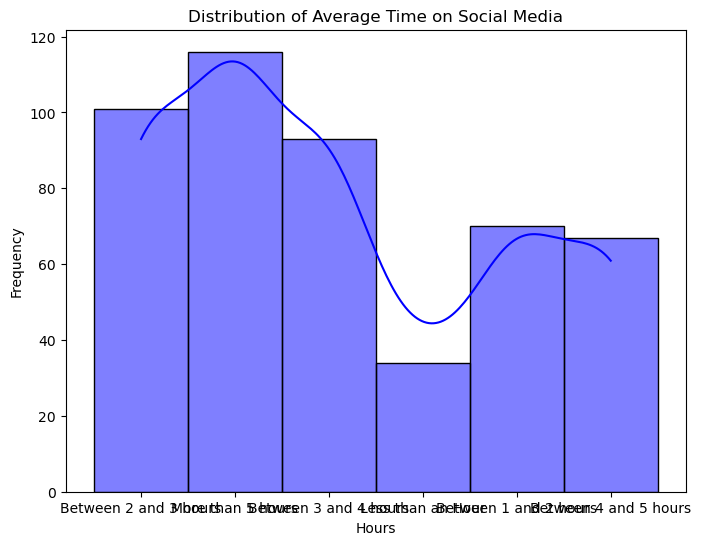

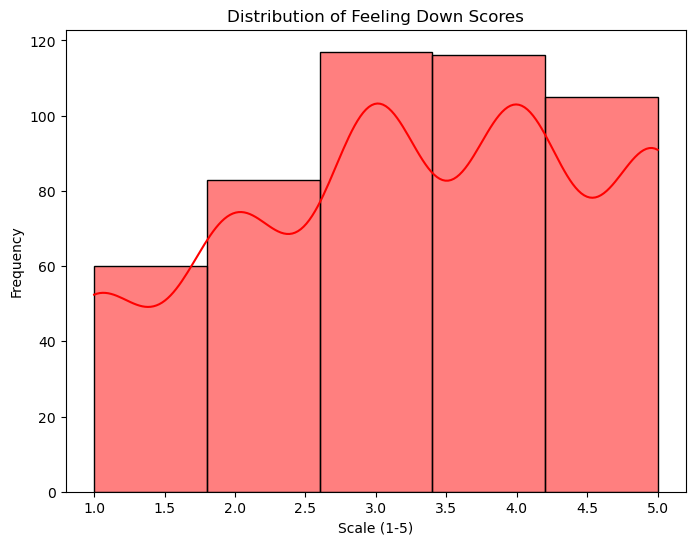

In [ ]:
# Distribution Analysis
plt.figure(figsize=(8, 6))
sns.histplot(data['AvgTimeOnSM'], bins=6, kde=True, color='blue')
plt.title('Distribution of Average Time on Social Media')
plt.xlabel('Hours')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8, 6))
sns.histplot(data['FeelingDown'], bins=5, kde=True, color='red')
plt.title('Distribution of Feeling Down Scores')
plt.xlabel('Scale (1-5)')
plt.ylabel('Frequency')
plt.show()

/var/folders/cj/m2vmffv12_12n55rcgbv_1xc0000gn/T/ipykernel_17933/3446776478.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='AvgTimeOnSM', y='FeelingDown', data=data, palette='coolwarm')


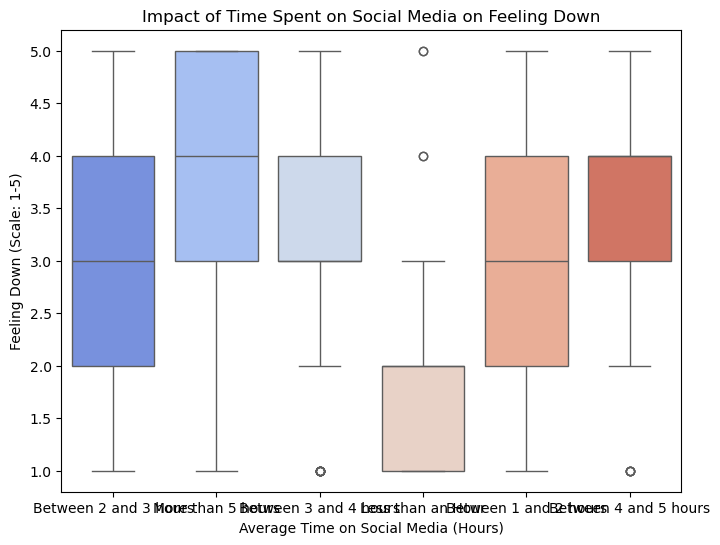

In [ ]:
# Trend Analysis by Social Media Usage
plt.figure(figsize=(8, 6))
sns.boxplot(x='AvgTimeOnSM', y='FeelingDown', data=data, palette='coolwarm')
plt.title('Impact of Time Spent on Social Media on Feeling Down')
plt.xlabel('Average Time on Social Media (Hours)')
plt.ylabel('Feeling Down (Scale: 1-5)')
plt.show()

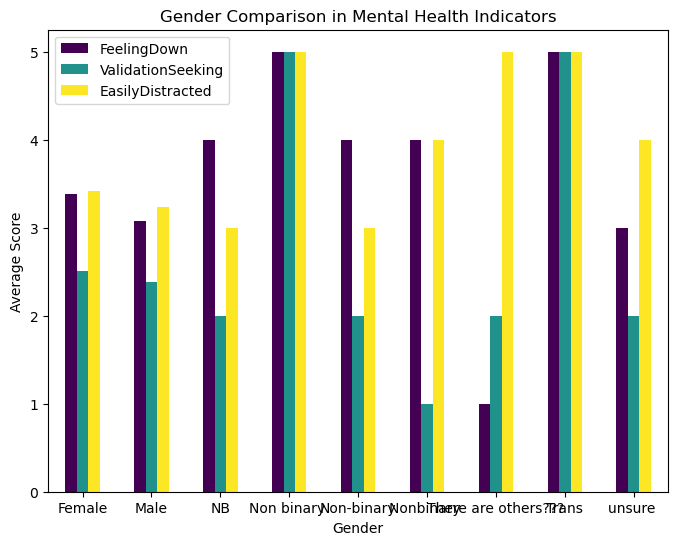

In [ ]:
# Comparison Across Genders
gender_comparison = data.groupby('Gender')[['FeelingDown', 'ValidationSeeking', 'EasilyDistracted']].mean()
gender_comparison.plot(kind='bar', figsize=(8, 6), colormap='viridis')
plt.title('Gender Comparison in Mental Health Indicators')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.show()

# **Analysing Political Events dataset**

In [ ]:
df = pd.read_csv('social_media_political_content_data_F.csv')
df.head()

,Age,Gender,Education Level,Occupation,Political Affiliation,Geographic Location,Social Media Usage Frequency,Preferred Social Media,Political Content Exposure,Types of Political Content,...,Political Content Topics,Perception of Accuracy,Awareness of Algorithms,Perception of Relevance,Personal Impact,Trust in Social Media,Concerns about Algorithms,Overall Quality of Discourse,Views on Influence,Suggestions for Improvement
0,38,Male,Bachelor's,Employed,Liberal,Australia,4+ hours,Instagram,Several times a day,Opinion pieces,...,Immigration,Very accurate,No,Not relevant,Strong impact,Trust a lot,Very concerned,Low quality,Very influential,Improve fact-checking
1,24,Male,Master's,Employed,Liberal,UK,1-2 hours,Instagram,Rarely,Opinion pieces,...,Environment,Very accurate,No,Very relevant,Moderate impact,Trust a lot,Not concerned,Low quality,Very influential,Provide more diverse sources
2,41,Male,Master's,Unemployed,Independent,UK,1-2 hours,Facebook,Once a day,News articles,...,Economy,Very accurate,Yes,Not relevant,No impact,Do not trust,Somewhat concerned,High quality,Very influential,Enhance user controls
3,8,Female,Bachelor's,Employed,Independent,UK,1-2 hours,Facebook,Several times a day,News articles,...,Environment,Not accurate,Yes,Not relevant,No impact,Trust somewhat,Not concerned,Low quality,Very influential,Increase transparency
4,41,Male,Master's,Student,Conservative,Canada,2-4 hours,Instagram,Once a day,Opinion pieces,...,Immigration,Very accurate,No,Somewhat relevant,No impact,Trust a lot,Not concerned,Moderate quality,Very influential,Enhance user controls


In [ ]:
df.shape

(12657, 22)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14530 entries, 0 to 14529
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Age                           14530 non-null  int64 
 1   Gender                        14530 non-null  object
 2   Occupation                    14530 non-null  object
 3   Political Affiliation         14530 non-null  object
 4   Geographic Location           14530 non-null  object
 5   Social Media Usage Frequency  14530 non-null  object
 6   Preferred Social Media        14530 non-null  object
 7   Political Content Exposure    14530 non-null  object
 8   Types of Political Content    14530 non-null  object
 9   Sources of Political Content  14530 non-null  object
 10  Recency of Exposure           14530 non-null  object
 11  Interactions Frequency        14530 non-null  object
 12  Political Content Topics      14530 non-null  object
 13  Perception of Ac

In [ ]:
df.describe()

,Age
count,14530.000000
mean,34.617756
std,15.011999
min,-31.000000
25%,24.250000
50%,35.000000
75%,45.000000
max,91.000000


In [ ]:
df['Gender'].value_counts()

,count
Gender,
Female,7223
Male,7025
Non-binary,282


In [ ]:
df.drop(columns=['Education Level'], inplace=True)

In [ ]:
df.sort_values('Age').head(5)

,Age,Gender,Occupation,Political Affiliation,Geographic Location,Social Media Usage Frequency,Preferred Social Media,Political Content Exposure,Types of Political Content,Sources of Political Content,...,Political Content Topics,Perception of Accuracy,Awareness of Algorithms,Perception of Relevance,Personal Impact,Trust in Social Media,Concerns about Algorithms,Overall Quality of Discourse,Views on Influence,Suggestions for Improvement
6080,18,Female,Student,Independent,Canada,1-2 hours,Twitter,Several times a day,News articles,Independent bloggers,...,Environment,Not accurate,Yes,Very relevant,Moderate impact,Trust somewhat,Somewhat concerned,High quality,Very influential,Enhance user controls
6057,18,Female,Employed,Conservative,USA,0-1 hour,Twitter,Rarely,Opinion pieces,Political parties,...,Economy,Not accurate,Yes,Not relevant,No impact,Do not trust,Somewhat concerned,High quality,Somewhat influential,Improve fact-checking
9067,18,Female,Student,Conservative,Australia,1-2 hours,Instagram,Rarely,Memes,Independent bloggers,...,Environment,Very accurate,No,Somewhat relevant,Strong impact,Do not trust,Very concerned,High quality,Very influential,Increase transparency
4931,18,Female,Employed,Conservative,USA,1-2 hours,Instagram,Several times a day,Opinion pieces,Independent bloggers,...,Healthcare,Very accurate,Yes,Somewhat relevant,Moderate impact,Trust somewhat,Very concerned,Moderate quality,Very influential,Enhance user controls
9040,18,Female,Student,Independent,USA,0-1 hour,Facebook,Once a day,News articles,Independent bloggers,...,Environment,Somewhat accurate,Yes,Somewhat relevant,Strong impact,Trust a lot,Somewhat concerned,Low quality,Somewhat influential,Improve fact-checking


In [ ]:
df = df[df['Age'] >= 18]

In [ ]:
df.shape

(12657, 22)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12657 entries, 0 to 14529
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Age                           12657 non-null  int64 
 1   Gender                        12657 non-null  object
 2   Occupation                    12657 non-null  object
 3   Political Affiliation         12657 non-null  object
 4   Geographic Location           12657 non-null  object
 5   Social Media Usage Frequency  12657 non-null  object
 6   Preferred Social Media        12657 non-null  object
 7   Political Content Exposure    12657 non-null  object
 8   Types of Political Content    12657 non-null  object
 9   Sources of Political Content  12657 non-null  object
 10  Recency of Exposure           12657 non-null  object
 11  Interactions Frequency        12657 non-null  object
 12  Political Content Topics      12657 non-null  object
 13  Perception of Accurac

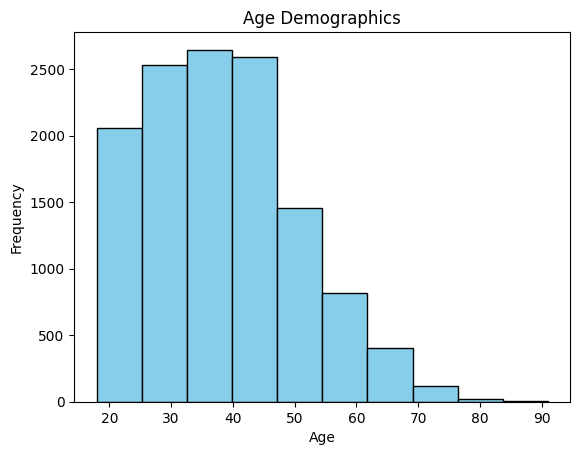

In [ ]:
plt.hist(df['Age'], bins=10, color='skyblue', edgecolor='black')
plt.title('Age Demographics')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [ ]:
df.to_csv('social_media_political_content_FP.csv', index=False)